# F1 AI/ML Series — Part 3: Predict the Race Winner 🏆

**Goal:** Train a Machine Learning model on 2025 F1 race data to predict 
race winners based on lap times, tyre strategy and track conditions.

**What this notebook covers:**
- Loading and combining multiple 2026 GP datasets
- Data cleaning and feature engineering
- Training a Random Forest model
- Evaluating model performance
- Predicting winners for upcoming races

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
import os

warnings.filterwarnings("ignore")

CACHE_DIR = "../f1_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

print("Ready!")

Ready!


## Step 1 — Loading 2025 Full Season Data
Loading all 24 races from the 2025 season and combining into one dataset.
Trained on 2025 to ensure regulation consistency — predicting 2026 as unseen data.

In [9]:
RACES_2025 = [
    "Bahrain", "Saudi Arabia", "Australia", "Japan", "China",
    "Miami", "Emilia Romagna", "Monaco", "Canada", "Spain",
    "Austria", "Britain", "Hungary", "Belgium", "Netherlands",
    "Italy", "Azerbaijan", "Singapore", "United States", "Mexico",
    "São Paulo", "Las Vegas", "Qatar", "Abu Dhabi"
]

all_laps = []

for race in RACES_2025:
    try:
        print(f"Loading {race}...")
        session = fastf1.get_session(2025, race, "R")
        session.load(telemetry=False)  # No telemetry needed for ML
        
        laps = session.laps.copy()
        laps["GP"] = race
        laps["Year"] = 2025
        all_laps.append(laps)
        print(f"{race} loaded — {len(laps)} laps")
        
    except Exception as e:
        print(f"{race} failed: {e}")

combined = pd.concat(all_laps, ignore_index=True)
print(f"\n Total laps across all races: {len(combined)}")
print(f"Races loaded: {combined['GP'].unique()}")

Loading Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Bahrain loaded — 1128 laps
Loading Saudi Arabia...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Failed to align laps for driver

Saudi Arabia loaded — 898 laps
Loading Australia...


...

Las Vegas loaded — 886 laps
Loading Qatar...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Qatar loaded — 1067 laps
Loading Abu Dhabi...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written t

Abu Dhabi loaded — 1156 laps

 Total laps across all races: 26689
Races loaded: ['Bahrain' 'Saudi Arabia' 'Australia' 'Japan' 'China' 'Miami'
 'Emilia Romagna' 'Monaco' 'Canada' 'Spain' 'Austria' 'Britain' 'Hungary'
 'Belgium' 'Netherlands' 'Italy' 'Azerbaijan' 'Singapore' 'United States'
 'Mexico' 'São Paulo' 'Las Vegas' 'Qatar' 'Abu Dhabi']


## Step 2 — Feature Engineering
Transforming raw lap data into model-ready features.
- Converting LapTime to seconds
- Normalising lap times within each race
- Encoding tyre compounds as numbers
- Creating binary target: IsWinner

In [10]:
# Convert LapTime to seconds
combined["LapTimeSeconds"] = combined["LapTime"].dt.total_seconds()

# Remove outliers — pit laps, safety car laps
clean = combined.dropna(subset=["LapTimeSeconds", "Position"])
clean = clean[clean["LapTimeSeconds"] > 0]
clean = clean.copy()

# Normalise lap times within each race
clean["GapToFastest"] = clean.groupby("GP")["LapTimeSeconds"].transform(
    lambda x: x - x.min()
)

# Encode tyre compound
le = LabelEncoder()
clean["CompoundEncoded"] = le.fit_transform(clean["Compound"].fillna("UNKNOWN"))

# Create target column
clean["IsWinner"] = (clean["Position"] == 1).astype(int)

print(f"Clean dataset: {len(clean)} laps")
print(f"\nWinner distribution:")
print(clean["IsWinner"].value_counts())
print(f"\nFeature preview:")
print(clean[["Driver", "GP", "LapTimeSeconds", "GapToFastest", 
             "TyreLife", "Stint", "CompoundEncoded", "IsWinner"]].head(10))

Clean dataset: 26337 laps

Winner distribution:
IsWinner
0    24912
1     1425
Name: count, dtype: int64

Feature preview:
  Driver       GP  LapTimeSeconds  GapToFastest  TyreLife  Stint  \
0    PIA  Bahrain          98.693         3.553       4.0    1.0   
1    PIA  Bahrain          97.492         2.352       5.0    1.0   
2    PIA  Bahrain          98.083         2.943       6.0    1.0   
3    PIA  Bahrain          98.133         2.993       7.0    1.0   
4    PIA  Bahrain          98.043         2.903       8.0    1.0   
5    PIA  Bahrain          98.363         3.223       9.0    1.0   
6    PIA  Bahrain          98.498         3.358      10.0    1.0   
7    PIA  Bahrain          98.567         3.427      11.0    1.0   
8    PIA  Bahrain          98.800         3.660      12.0    1.0   
9    PIA  Bahrain          98.549         3.409      13.0    1.0   

   CompoundEncoded  IsWinner  
0                4         1  
1                4         1  
2                4         1  
3   

## Step 3 — Training the Model
Splitting data into train/test sets and training a Random Forest classifier.
Using class_weight="balanced" to handle winner/non-winner imbalance.

In [14]:
# Define features and target
FEATURES = ["GapToFastest", "TyreLife", "Stint", 
            "CompoundEncoded", "LapNumber"]
TARGET = "IsWinner"

# Drop rows with missing values in our feature columns
model_data = clean.dropna(subset=FEATURES + [TARGET])

X = model_data[FEATURES]
y = model_data[TARGET]

# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    min_samples_leaf=2,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

# Also try lower prediction threshold
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_pred_proba >= 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned,
      target_names=["Not Winner", "Winner"]))


Training samples: 20722
Testing samples: 5181
              precision    recall  f1-score   support

  Not Winner       0.98      0.84      0.90      4907
      Winner       0.19      0.66      0.29       274

    accuracy                           0.83      5181
   macro avg       0.58      0.75      0.60      5181
weighted avg       0.94      0.83      0.87      5181



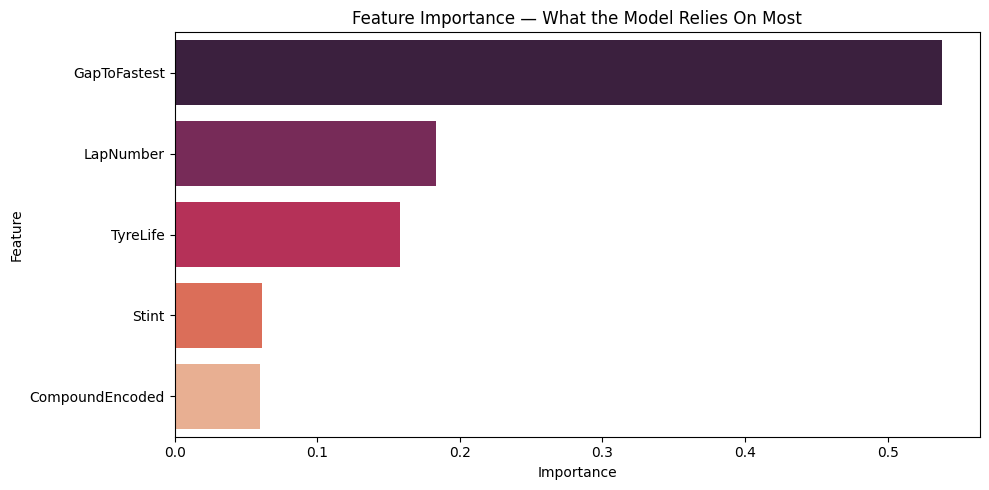

           Feature  Importance
0     GapToFastest    0.537910
4        LapNumber    0.183476
1         TyreLife    0.157727
2            Stint    0.061329
3  CompoundEncoded    0.059558


In [13]:
feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="rocket")
plt.title("Feature Importance — What the Model Relies On Most")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(feature_importance)

## Step 5 — Predicting the 2026 Monaco GP 🏆
Using our 2025-trained model to predict win probabilities for the upcoming Monaco GP.
Note: This is a cross-regulation prediction — 2025 patterns applied to 2026 season.
Monaco is the most regulation-agnostic circuit due to its street layout and 
overtaking difficulty, making it the best candidate for cross-season prediction.

In [16]:
# Simulate Monaco GP inputs for top drivers
monaco_drivers = {
    "ANT": {"GapToFastest": 0.1, "TyreLife": 25, "Stint": 2, "CompoundEncoded": 0, "LapNumber": 50},
    "RUS": {"GapToFastest": 0.2, "TyreLife": 25, "Stint": 2, "CompoundEncoded": 0, "LapNumber": 50},
    "NOR": {"GapToFastest": 0.4, "TyreLife": 25, "Stint": 2, "CompoundEncoded": 0, "LapNumber": 50},
    "VER": {"GapToFastest": 0.5, "TyreLife": 25, "Stint": 2, "CompoundEncoded": 0, "LapNumber": 50},
    "LEC": {"GapToFastest": 0.3, "TyreLife": 25, "Stint": 2, "CompoundEncoded": 0, "LapNumber": 50},
    "HAM": {"GapToFastest": 0.6, "TyreLife": 25, "Stint": 2, "CompoundEncoded": 0, "LapNumber": 50},
}

monaco_df = pd.DataFrame(monaco_drivers).T
monaco_df.columns = FEATURES

# Get win probability for each driver
win_proba = model.predict_proba(monaco_df)[:, 1]

results = pd.DataFrame({
    "Driver": monaco_drivers.keys(),
    "WinProbability": win_proba
}).sort_values("WinProbability", ascending=False)

print("Monaco GP 2026 — Predicted Win Probability")
print(results.to_string(index=False))

Monaco GP 2026 — Predicted Win Probability
Driver  WinProbability
   VER        0.724722
   NOR        0.718836
   HAM        0.686020
   LEC        0.657023
   RUS        0.583639
   ANT        0.512462
